In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("06-study_hours_grades.csv")

In [3]:
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [5]:
#X = torch.tensor(df['study_hours'].values)
X = torch.tensor(df['study_hours'].values, dtype=torch.float32).unsqueeze(1) # linear layer default 32 bit istiyor
#y = torch.tensor(df['grade'].values)
y = torch.tensor(df['grade'].values, dtype=torch.float32).unsqueeze(1)

In [6]:
X.shape

torch.Size([50, 1])

In [7]:
X.ndim

2

In [8]:
y.shape

torch.Size([50, 1])

In [9]:
y.ndim

2

In [10]:
X

tensor([[3.7454],
        [9.5071],
        [7.3199],
        [5.9866],
        [1.5602],
        [1.5599],
        [0.5808],
        [8.6618],
        [6.0111],
        [7.0807],
        [0.2058],
        [9.6991],
        [8.3244],
        [2.1234],
        [1.8182],
        [1.8340],
        [3.0424],
        [5.2476],
        [4.3195],
        [2.9123],
        [6.1185],
        [1.3949],
        [2.9214],
        [3.6636],
        [4.5607],
        [7.8518],
        [1.9967],
        [5.1423],
        [5.9241],
        [0.4645],
        [6.0754],
        [1.7052],
        [0.6505],
        [9.4889],
        [9.6563],
        [8.0840],
        [3.0461],
        [0.9767],
        [6.8423],
        [4.4015],
        [1.2204],
        [4.9518],
        [0.3439],
        [9.0932],
        [2.5878],
        [6.6252],
        [3.1171],
        [5.2007],
        [5.4671],
        [1.8485]])

In [11]:
y

tensor([[30.2039],
        [57.8785],
        [46.3684],
        [39.3307],
        [14.8439],
        [16.3600],
        [11.9829],
        [55.4230],
        [40.7430],
        [41.8775],
        [11.6774],
        [57.7253],
        [50.2683],
        [21.8403],
        [21.1532],
        [21.0328],
        [23.5337],
        [35.6194],
        [32.2598],
        [26.5125],
        [39.6343],
        [16.6034],
        [22.3946],
        [25.9257],
        [34.4286],
        [51.9713],
        [19.8397],
        [37.7188],
        [40.3440],
        [11.0323],
        [41.1000],
        [21.6023],
        [13.1809],
        [60.5736],
        [53.0421],
        [52.0637],
        [25.4048],
        [14.2856],
        [44.3952],
        [28.0325],
        [15.6626],
        [35.4731],
        [14.6752],
        [54.4295],
        [21.3220],
        [42.1226],
        [27.4164],
        [36.6609],
        [36.2760],
        [20.2693]])

In [12]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [13]:
len(X_train),len(X_test)

(40, 10)

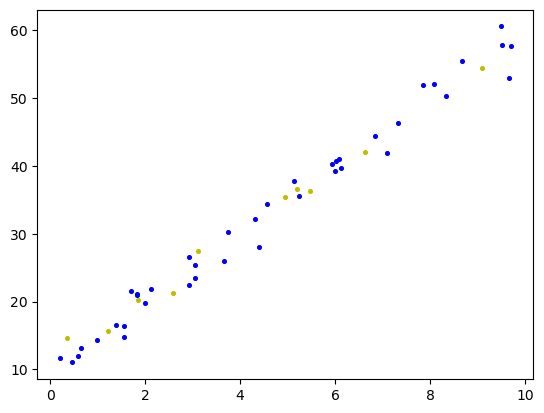

In [14]:
plt.scatter(X_train, y_train, c="b", s=7, label="Training data")
plt.scatter(X_test, y_test, c="y", s=7, label="Testing data")
plt.show()

In [15]:
#from torch import nn
import torch.nn as nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer = nn.Linear(in_features=1, out_features=1, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [16]:
torch.manual_seed(42)
model = LinearRegressionModel()

In [17]:
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [18]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [19]:
list(model.parameters())

[Parameter containing:
 tensor([[0.7645]], requires_grad=True),
 Parameter containing:
 tensor([0.8300], requires_grad=True)]

In [20]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(params = model.parameters(), lr = 0.001)

In [21]:
epochs = 200

for epoch in range(epochs):
    
    model.train() 

    # 1. Forward pass
    y_pred = model(X_train)

    # 2. loss calculation
    loss = loss_fn(y_pred, y_train)

    # 3. reset optimizer
    optimizer.zero_grad()

    # 4. backward prop
    loss.backward()

    # 5. optimize the weights
    optimizer.step()

    # Test steps
    model.eval() 
    with torch.inference_mode():
        test_pred = model(X_test)
        # 2. test loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 5 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 965.6339111328125 | Test loss: 717.6834106445312
Epoch: 5 | Train loss: 530.086669921875 | Test loss: 405.685546875
Epoch: 10 | Train loss: 295.73614501953125 | Test loss: 236.0322723388672
Epoch: 15 | Train loss: 169.6184539794922 | Test loss: 143.42544555664062
Epoch: 20 | Train loss: 101.72415924072266 | Test loss: 92.61088562011719
Epoch: 25 | Train loss: 65.15110778808594 | Test loss: 64.53107452392578
Epoch: 30 | Train loss: 45.427330017089844 | Test loss: 48.86598587036133
Epoch: 35 | Train loss: 34.76780319213867 | Test loss: 40.014488220214844
Epoch: 40 | Train loss: 28.9846248626709 | Test loss: 34.927181243896484
Epoch: 45 | Train loss: 25.82492446899414 | Test loss: 31.93711280822754
Epoch: 50 | Train loss: 24.0767879486084 | Test loss: 30.128173828125
Epoch: 55 | Train loss: 23.088253021240234 | Test loss: 28.993366241455078
Epoch: 60 | Train loss: 22.508625030517578 | Test loss: 28.2496337890625
Epoch: 65 | Train loss: 22.149234771728516 | Test loss

In [44]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[6.1576]])),
             ('linear_layer.bias', tensor([2.5799]))])

In [46]:
model.eval()
with torch.inference_mode():
    y_preds = model(X_test)

In [48]:
y_preds

tensor([[10.0945],
        [33.0710],
        [ 4.6974],
        [58.5723],
        [18.5145],
        [43.3754],
        [21.7738],
        [34.6037],
        [36.2442],
        [13.9625]])

In [50]:
y_test

tensor([[15.6626],
        [35.4731],
        [14.6752],
        [54.4295],
        [21.3220],
        [42.1226],
        [27.4164],
        [36.6609],
        [36.2760],
        [20.2693]])

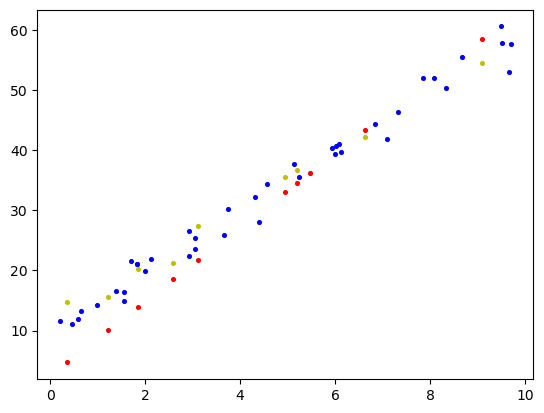

In [56]:
plt.scatter(X_train, y_train, c="b", s=7, label="Training data")
plt.scatter(X_test, y_test, c="y", s=7, label="Testing data")
plt.scatter(X_test, y_preds, c="r", s=7, label="Predicted data")
plt.show()

In [ ]:
# linear bir dataset oldugu icin aktivasyon func koymadik